# Author's Notes

This `.ipynb` file is dedicated to plotting the distributions of various parameters in the constructed `UltraDeep.h5` file. 

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataframe = pd.read_hdf("..\\data_preprocessing\\UltraDeep.h5")

In [3]:
clean_academic = {
    # Typography (LaTeX style)
    'font.family': 'serif',
    "mathtext.fontset" : "cm",
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 10,
    
    # Layout
    'figure.figsize': (6.5, 4.5),  # Standard column width
    'figure.dpi': 150,             # Higher resolution for print
    'axes.spines.top': True,
    'axes.spines.right': True,
    
    # Grid & Axes
    'axes.grid': True,
    'grid.color': "#D3D3D3",
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    
    # High-contrast palette
    'axes.prop_cycle': plt.cycler(color=['#111111', '#004488', '#D55E00', '#009E73']),
    
    # Lines & Markers
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
}

plt.rcParams.update(clean_academic)

In [4]:
df = dataframe[(dataframe["ZFLAGS"] % 10 == 4) | (dataframe["ZFLAGS"] % 10 == 3)]

# 1D Distributions

Here, we plot the one-dimensional distribution of various parameters of galaxies with flags ending with either 3 or 4 (high redshift reliability).

In [5]:
hist1 = {'histtype': 'step', 'color': 'blue', 'fill': True,  'edgecolor': 'blue', 'linewidth': 2, 'alpha': 0.3}
hist2 = {'histtype': 'step', 'color': 'red', 'fill': True,  'edgecolor': 'red', 'linewidth': 2, 'alpha': 0.3}

In [6]:
df3 = df[df["ZFLAGS"] % 10 == 3] # Flags end with 3
df4 = df[df["ZFLAGS"] % 10 == 4] # Flags end with 4

In [7]:
print(len(df3))
print(len(df4))
print(len(df))

343
166
509


## Redshift Distribution

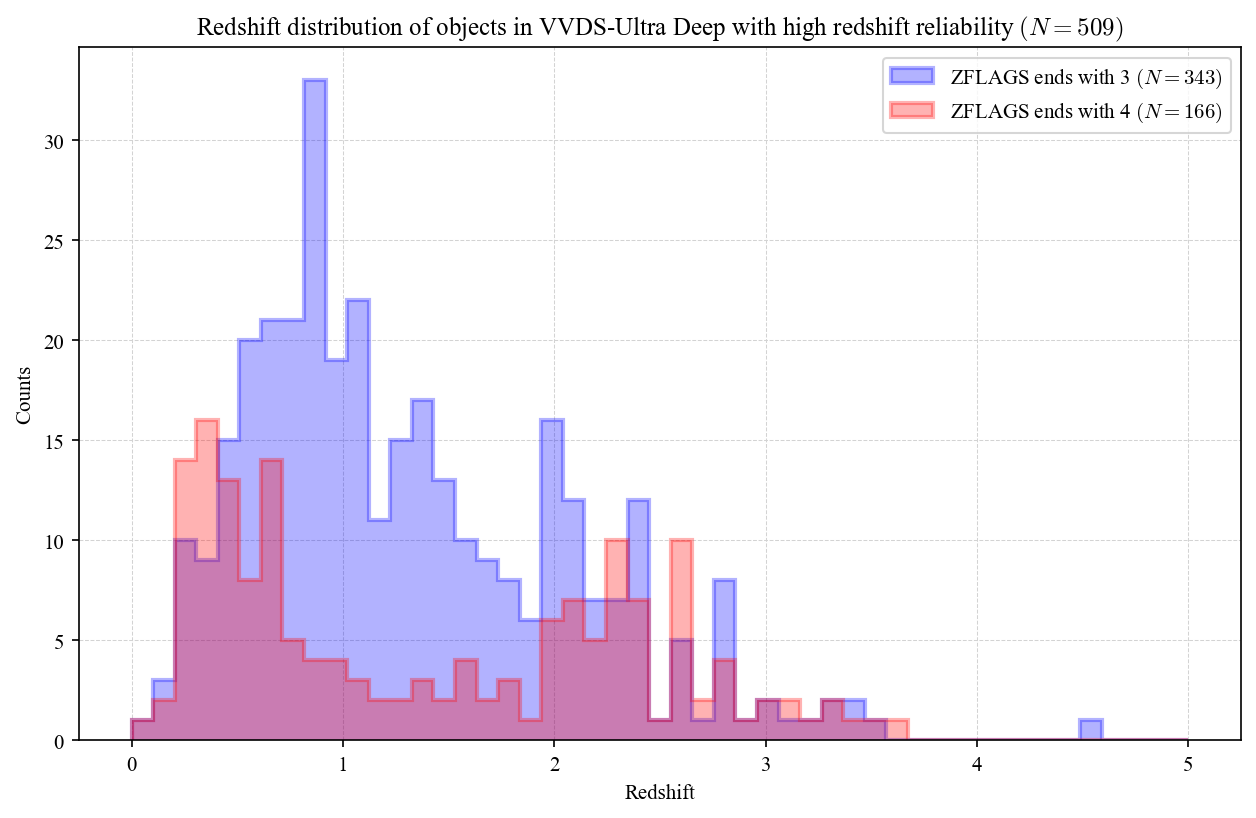

In [8]:
hist_bins = np.linspace(0, 5, 50)

plt.subplots(figsize = (10, 6))
plt.hist(df3["Z"], bins = hist_bins, label = r"ZFLAGS ends with 3 $(N=343)$", **hist1)
plt.hist(df4["Z"], bins = hist_bins, label = r"ZFLAGS ends with 4 $(N=166)$", **hist2)

plt.legend(loc = "upper right")
plt.xlabel("Redshift")
plt.ylabel("Counts")
plt.title(r"Redshift distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

## Magnitude Distribution

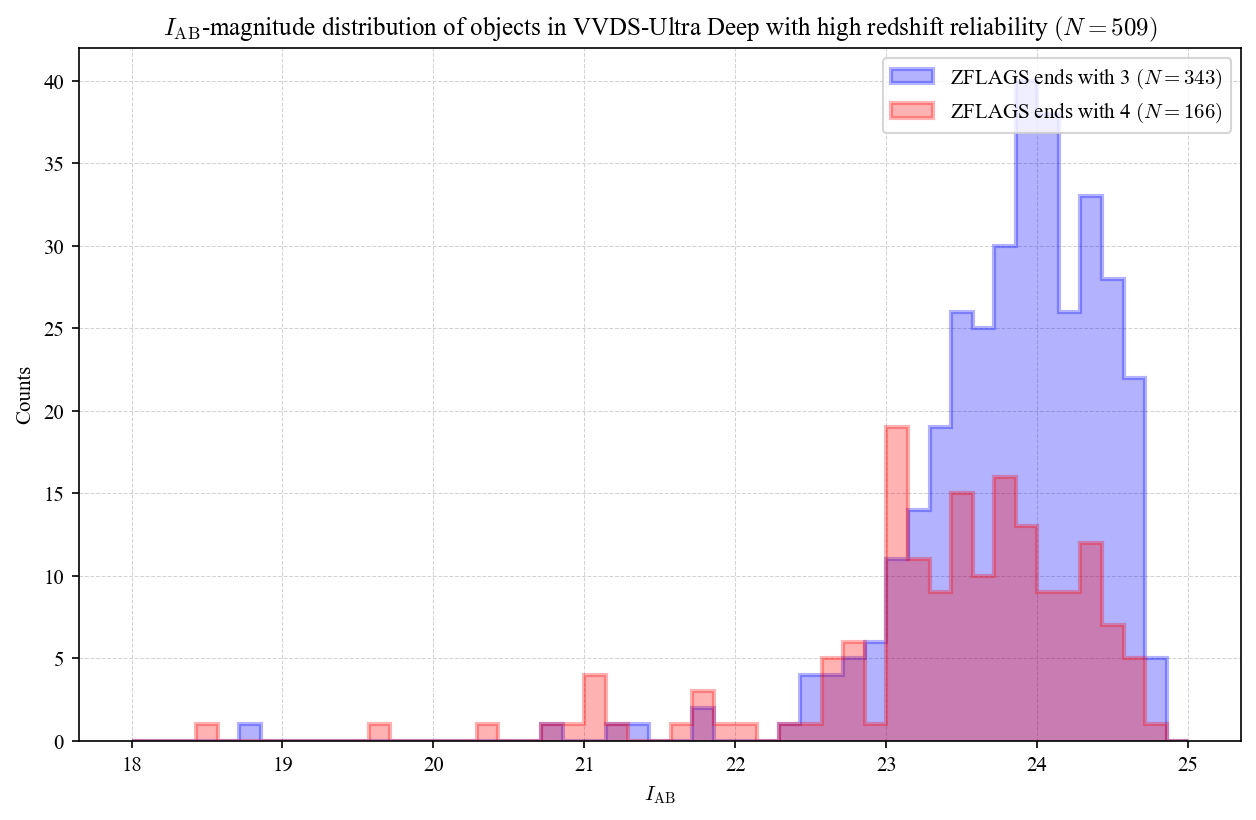

In [9]:
hist_bins = np.linspace(18, 25, 50)

plt.subplots(figsize = (10, 6))
plt.hist(df3["MAGI"], bins = hist_bins, label = r"ZFLAGS ends with 3 $(N=343)$", **hist1)
plt.hist(df4["MAGI"], bins = hist_bins, label = r"ZFLAGS ends with 4 $(N=166)$", **hist2)

plt.legend(loc = "upper right")
plt.xlabel(r"$I_\mathrm{AB}$")
plt.ylabel("Counts")
plt.title(r"$I_\mathrm{AB}$-magnitude distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

## Stellar Mass Distribution

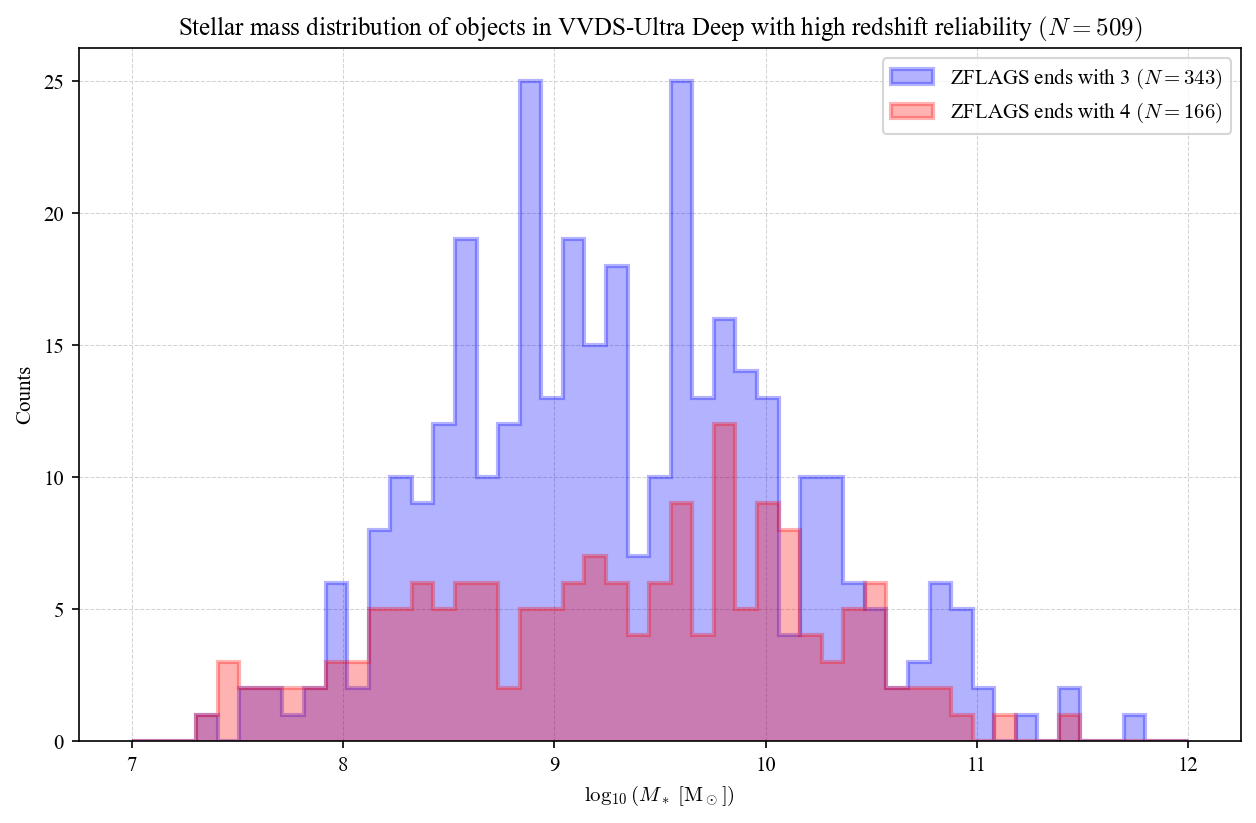

In [10]:
hist_bins = np.linspace(7, 12, 50)

plt.subplots(figsize = (10, 6))
plt.hist(df3["stellar_mass"], bins = hist_bins, label = r"ZFLAGS ends with 3 $(N=343)$", **hist1)
plt.hist(df4["stellar_mass"], bins = hist_bins, label = r"ZFLAGS ends with 4 $(N=166)$", **hist2)

plt.legend(loc = "upper right")
plt.xlabel(r"$\log_{10}(M_*\;[\mathrm{M}_\odot])$")
plt.ylabel("Counts")
plt.title(r"Stellar mass distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

## Star Formation Rate Distribution

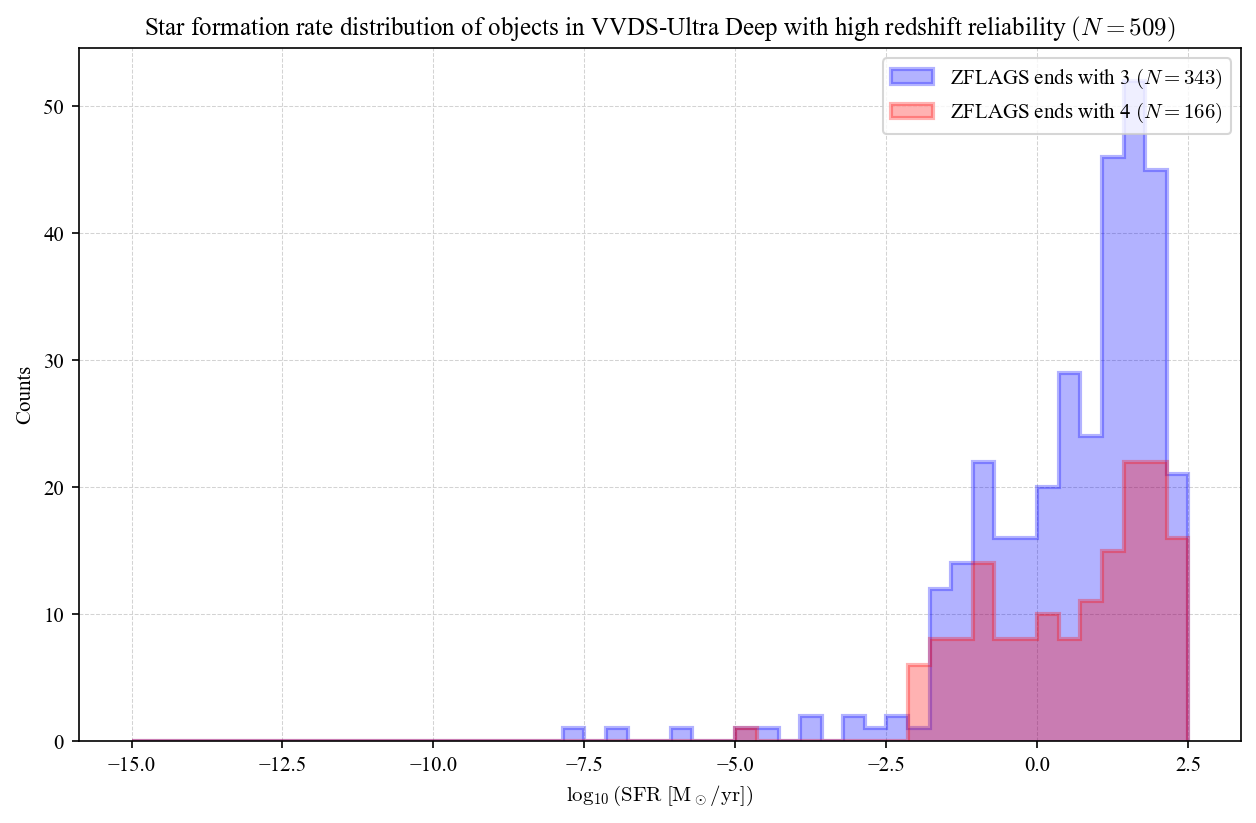

In [11]:
hist_bins = np.linspace(-15, 2.5, 50)

plt.subplots(figsize = (10, 6))
plt.hist(df3["sfr"], bins = hist_bins, label = r"ZFLAGS ends with 3 $(N=343)$", **hist1)
plt.hist(df4["sfr"], bins = hist_bins, label = r"ZFLAGS ends with 4 $(N=166)$", **hist2)

plt.legend(loc = "upper right")
plt.xlabel(r"$\log_{10}(\mathrm{SFR}\;[\mathrm{M}_\odot/\mathrm{yr}])$")
plt.ylabel("Counts")
plt.title(r"Star formation rate distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

## Specific Star Formation Rate Distribution

The specific star formation rate (sSFR or SSFR) is defined by 

$$ \text{sSFR} = \frac{\text{SFR}}{M_*}\quad\text{or}\quad \log_{10}\text{sSFR} = \log_{10}\frac{\text{SFR}}{M_*}. $$

In [12]:
df3["ssfr"] = df3["sfr"] - df3["stellar_mass"] # in log
df4["ssfr"] = df4["sfr"] - df4["stellar_mass"] # in log

C:\Users\User\AppData\Local\Temp\ipykernel_14444\2717115474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["ssfr"] = df3["sfr"] - df3["stellar_mass"] # in log
C:\Users\User\AppData\Local\Temp\ipykernel_14444\2717115474.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4["ssfr"] = df4["sfr"] - df4["stellar_mass"] # in log


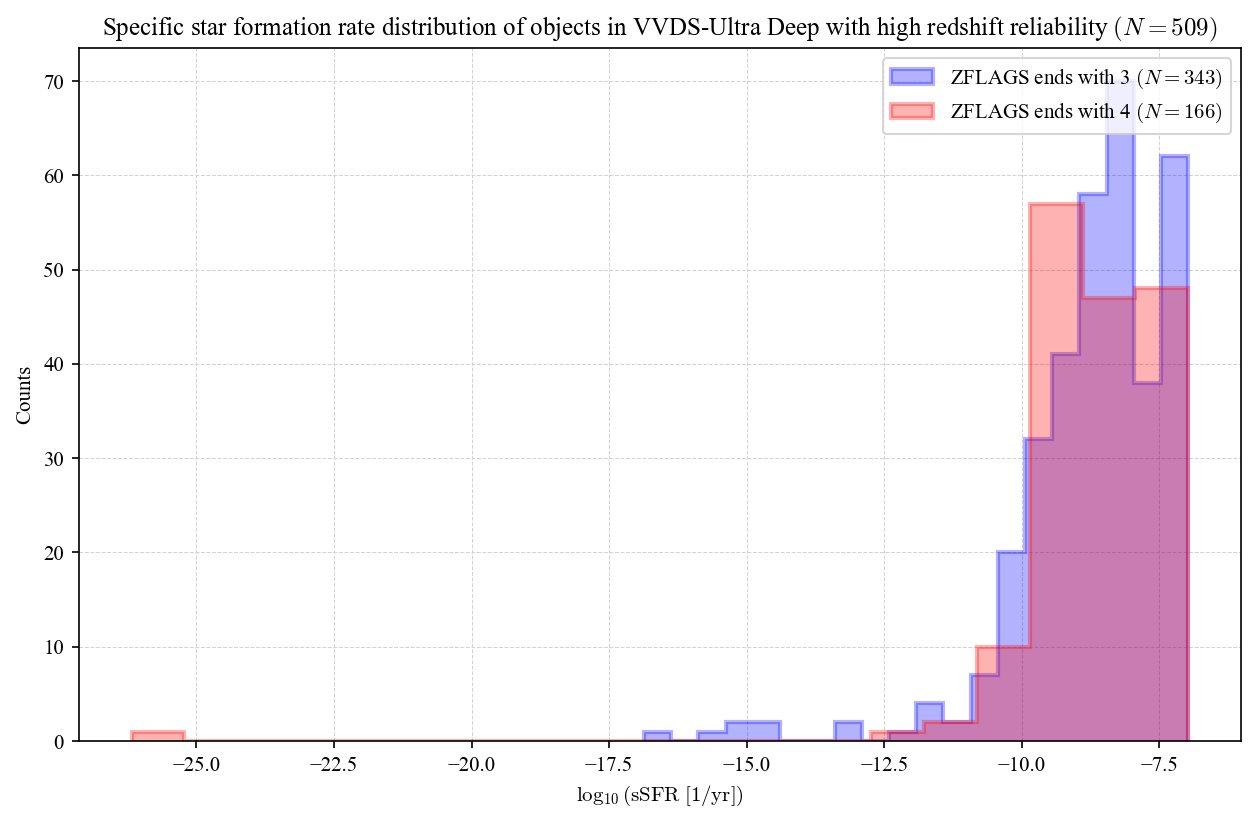

In [16]:
hist_bins = np.linspace(-30, -6, 50)
hist_bins = 20

plt.subplots(figsize = (10, 6))
plt.hist(df3["ssfr"], bins = hist_bins, label = r"ZFLAGS ends with 3 $(N=343)$", **hist1)
plt.hist(df4["ssfr"], bins = hist_bins, label = r"ZFLAGS ends with 4 $(N=166)$", **hist2)

plt.legend(loc = "upper right")
plt.xlabel(r"$\log_{10}(\mathrm{sSFR}\;[1/\mathrm{yr}])$")
plt.ylabel("Counts")
plt.title(r"Specific star formation rate distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

# 2D Distributions

In [24]:
scatter1 = {"color": "blue", "alpha": 0.3, "s": 5}
scatter2 = {"color": "red", "alpha": 0.3, "s": 5}

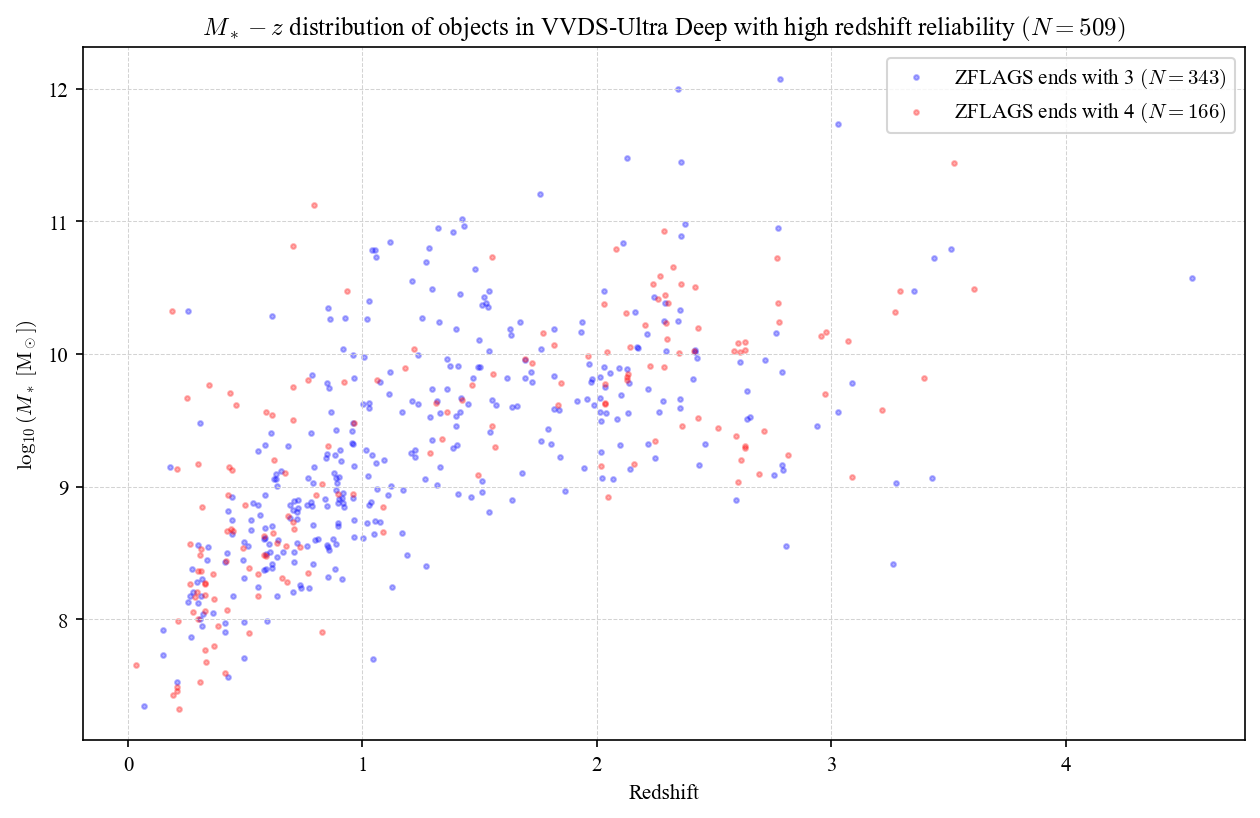

In [26]:
plt.subplots(figsize = (10, 6))
plt.scatter(df3["Z"], df3["stellar_mass"], label = r"ZFLAGS ends with 3 $(N=343)$", **scatter1)
plt.scatter(df4["Z"], df4["stellar_mass"], label = r"ZFLAGS ends with 4 $(N=166)$", **scatter2)

plt.legend(loc = "upper right")
plt.xlabel("Redshift")
plt.ylabel(r"$\log_{10}(M_*\;[\mathrm{M}_\odot])$")
plt.title(r"$M_*-z$ distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

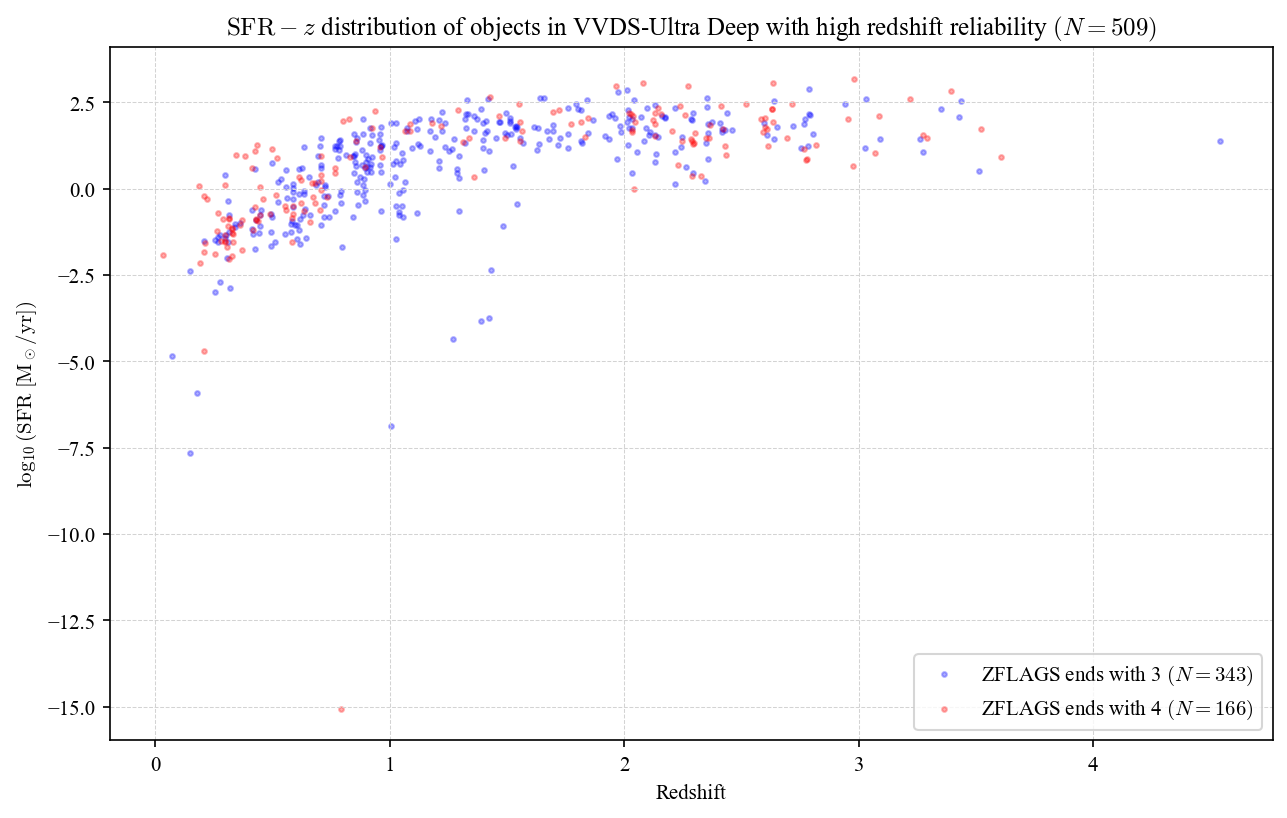

In [28]:
plt.subplots(figsize = (10, 6))
plt.scatter(df3["Z"], df3["sfr"], label = r"ZFLAGS ends with 3 $(N=343)$", **scatter1)
plt.scatter(df4["Z"], df4["sfr"], label = r"ZFLAGS ends with 4 $(N=166)$", **scatter2)

plt.legend(loc = "lower right")
plt.xlabel("Redshift")
plt.ylabel(r"$\log_{10}(\mathrm{SFR}\;[\mathrm{M}_\odot/\mathrm{yr}])$")
plt.title(r"$\mathrm{SFR}-z$ distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

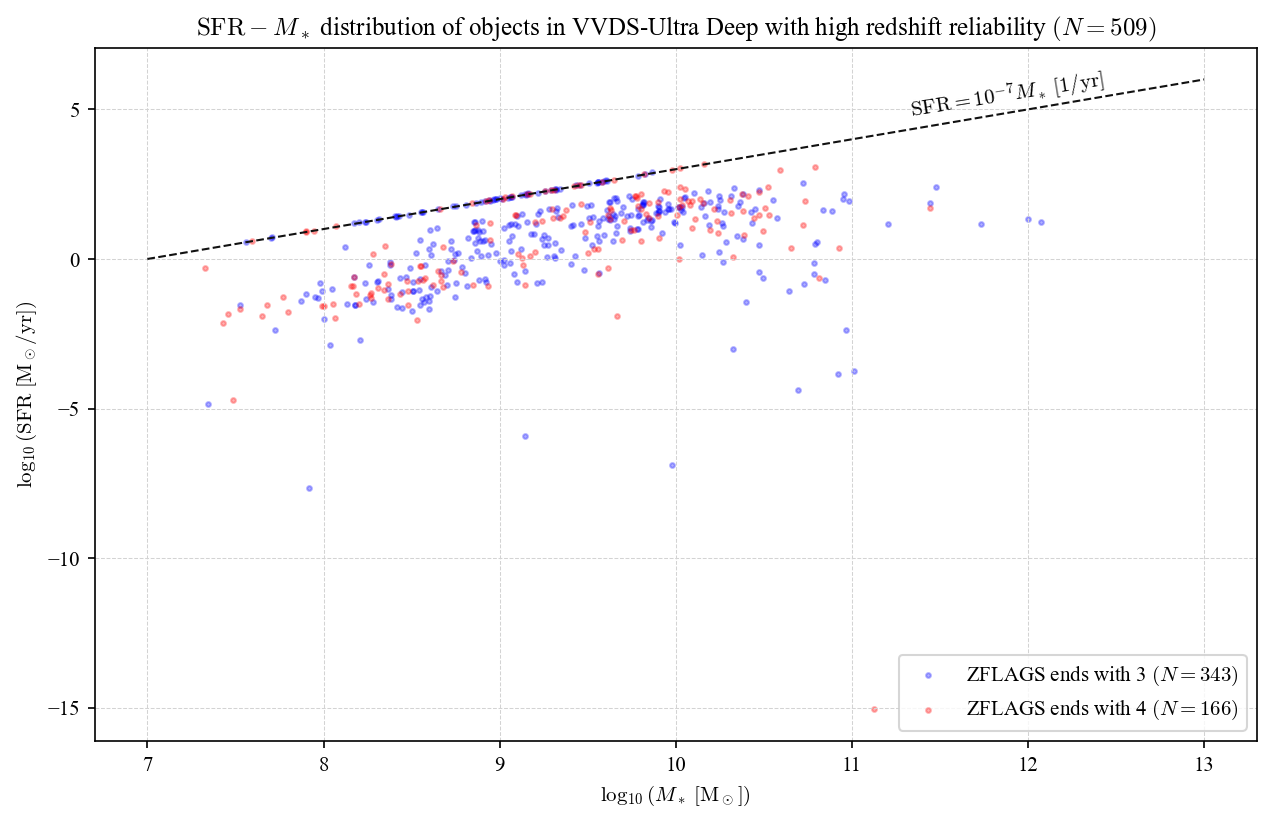

In [53]:
line_x = np.linspace(7, 13, 50)

plt.subplots(figsize = (10, 6))
plt.scatter(df3["stellar_mass"], df3["sfr"], label = r"ZFLAGS ends with 3 $(N=343)$", **scatter1)
plt.scatter(df4["stellar_mass"], df4["sfr"], label = r"ZFLAGS ends with 4 $(N=166)$", **scatter2)

ax = plt.gca()

# threshold
plt.plot(line_x, 1 * line_x - 7, linewidth = 1, linestyle = "--")
plt.text(0.7, 0.9, r"$\mathrm{SFR}=10^{-7}M_*\;[1/\mathrm{yr}]$", rotation = 9.13, transform=ax.transAxes)

plt.legend(loc = "lower right")
plt.xlabel(r"$\log_{10}(M_*\;[\mathrm{M}_\odot])$")
plt.ylabel(r"$\log_{10}(\mathrm{SFR}\;[\mathrm{M}_\odot/\mathrm{yr}])$")
plt.title(r"$\mathrm{SFR}-M_*$ distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()

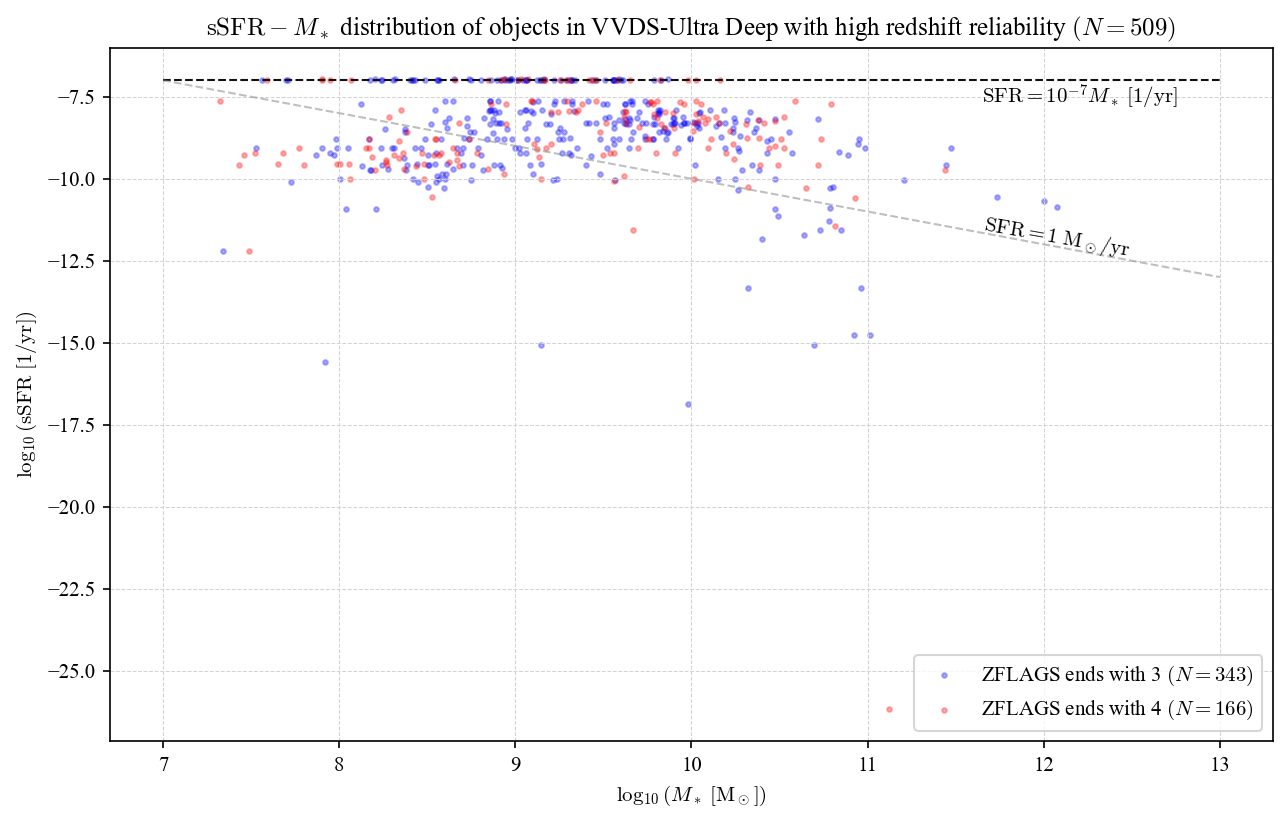

In [76]:
line_x = np.linspace(7, 13, 50)

plt.subplots(figsize = (10, 6))
plt.scatter(df3["stellar_mass"], df3["ssfr"], label = r"ZFLAGS ends with 3 $(N=343)$", **scatter1)
plt.scatter(df4["stellar_mass"], df4["ssfr"], label = r"ZFLAGS ends with 4 $(N=166)$", **scatter2)

ax = plt.gca()

# constant sSFR

plt.plot(line_x, -7 * np.ones_like(line_x), linewidth = 1, linestyle = "--")
plt.text(0.75, 0.92, r"$\mathrm{SFR} = 10^{-7}M_*\;[1/\mathrm{yr}]$", transform = ax.transAxes)

# constant SFR 
# log(sSFR) = log(SFR) - log(M)

plt.text(0.75, 0.7, r"$\mathrm{SFR} = 1\;\mathrm{M}_\odot/\mathrm{yr}$", transform = ax.transAxes, rotation = -10)
plt.plot(line_x, 0 - line_x, linewidth = 1, linestyle = "--", alpha = 0.5, color = "gray")

plt.legend(loc = "lower right")
plt.xlabel(r"$\log_{10}(M_*\;[\mathrm{M}_\odot])$")
plt.ylabel(r"$\log_{10}(\mathrm{sSFR}\;[1/\mathrm{yr}])$")
plt.title(r"$\mathrm{sSFR}-M_*$ distribution of objects in VVDS-Ultra Deep with high redshift reliability $(N=509)$")
plt.show()